# System Dynamics Scenario Analysis

## Clean Implementation of Multi-Scenario Population Modeling

This notebook demonstrates system dynamics modeling with separate YAML files for model structure and scenario parameters, focusing on clean workflow and essential results.

### Key Features:
- 🏗️ **Separate Model Structure**: Model definition in YAML
- 📋 **Scenario Parameters**: Parameter values in separate files
- 🔄 **Multiple Scenarios**: Easy comparison of different parameter sets
- 🧮 **Calculator Components**: Arithmetic operations on flows and stocks
- 📊 **Multidimensional Data**: Population by age, income, and region
- 📈 **Comparative Analysis**: Side-by-side scenario results

---

## Setup and Imports

In [11]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from pathlib import Path
import yaml
import warnings
import copy
import sys
import os
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Add toolkit to path
sys.path.insert(0, os.path.join('..', 'sd_toolkit'))

# Import System Dynamics Toolkit
from sd_toolkit.config import YAMLSystemBuilder, TemplateManager, rate_registry
from sd_toolkit.engine.system import SystemModel
from sd_toolkit.engine.elements import Stock, Flow, Auxiliary, Calculator
from sd_toolkit.data.loader import SpatioTemporalData
from sd_toolkit.analysis.plotting import SystemPlotter
from sd_toolkit.core.units import Q_, unit_registry

print("✅ System Dynamics Toolkit loaded successfully!")

✅ System Dynamics Toolkit loaded successfully!


## Load Model Structure and Scenarios

In [12]:
# Define file paths
model_structure_path = Path('yaml_models/simple_population_model.yaml')
scenario_files = {
    'Baseline': Path('yaml_models/baseline_scenario.yaml'),
    'High Immigration': Path('yaml_models/high_immigration_scenario.yaml')
}

# Load model structure
with open(model_structure_path, 'r') as file:
    model_structure = yaml.safe_load(file)

print(f"Model: {model_structure['model']['name']}")
print(f"Time horizon: {model_structure['model']['time_horizon']} {model_structure['model']['time_units']}")

# Load scenarios
scenarios = {}
for scenario_name, scenario_path in scenario_files.items():
    with open(scenario_path, 'r') as file:
        scenario_data = yaml.safe_load(file)
    scenarios[scenario_name] = scenario_data
    print(f"✅ {scenario_name}: {scenario_data['scenario']['description']}")

print(f"\nLoaded {len(scenarios)} scenarios")

Model: Simple Population Model
Time horizon: 50 year
✅ Baseline: Basic population dynamics with moderate conditions
✅ High Immigration: Population dynamics with increased immigration rates

Loaded 2 scenarios


## Merge Model with Scenario Parameters

In [13]:
def merge_model_with_scenario(model_structure, scenario_data):
    """Merge model structure with scenario parameters."""
    complete_model = copy.deepcopy(model_structure)
    
    # Override constants with scenario values
    if 'constants' in scenario_data:
        if 'constants' not in complete_model:
            complete_model['constants'] = {}
        complete_model['constants'].update(scenario_data['constants'])
    
    # Override model configuration if present
    if 'model_config' in scenario_data:
        complete_model['model'].update(scenario_data['model_config'])
    
    # Add scenario metadata
    complete_model['scenario_info'] = scenario_data.get('scenario', {})
    
    return complete_model

# Create complete model configurations
complete_models = {}
for scenario_name, scenario_data in scenarios.items():
    complete_model = merge_model_with_scenario(model_structure, scenario_data)
    complete_models[scenario_name] = complete_model

print(f"Created {len(complete_models)} complete model configurations")

Created 2 complete model configurations


## Build and Validate Models

In [14]:
# Build models
built_models = {}
builder = YAMLSystemBuilder()

for scenario_name, model_config in complete_models.items():
    try:
        model = builder.build_from_dict(model_config)
        model.name = f"{model.name} - {scenario_name}"
        
        validation = model.validate_model()
        built_models[scenario_name] = model
        
        print(f"✅ {scenario_name}: {len(model.stocks)} stocks, {len(model.flows)} flows, {len(model.calculators)} calculators")
        
        if not validation['valid']:
            print(f"   ⚠️ Warnings: {len(validation.get('warnings', []))}")
        
    except Exception as e:
        print(f"❌ Failed to build {scenario_name}: {e}")

print(f"\nSuccessfully built {len(built_models)} models")

✅ Baseline: 1 stocks, 4 flows, 3 calculators
✅ High Immigration: 1 stocks, 4 flows, 3 calculators

Successfully built 2 models


## Run Simulations

In [15]:
# Run simulations
simulation_results = {}

for scenario_name, model in built_models.items():
    try:
        results = model.simulate(
            time_horizon=model.time_horizon,
            dt=model.dt
        )
        simulation_results[scenario_name] = results
        
        # Show key results
        if 'Population' in results.columns:
            initial_pop = results['Population'].iloc[0]
            final_pop = results['Population'].iloc[-1]
            growth_rate = ((final_pop / initial_pop) ** (1/model.time_horizon) - 1) * 100
            
            print(f"✅ {scenario_name}: {initial_pop:,.0f} → {final_pop:,.0f} ({growth_rate:+.2f}% annually)")
        
    except Exception as e:
        print(f"❌ {scenario_name} simulation failed: {e}")

print(f"\nCompleted {len(simulation_results)} simulations")

✅ Baseline: 22,300 → 32,200 (+0.74% annually)
✅ High Immigration: 22,300 → 106,000 (+3.17% annually)

Completed 2 simulations


## Results Analysis

In [16]:
# Create comparison table
if simulation_results:
    comparison_data = []
    
    for scenario_name, results in simulation_results.items():
        if 'Population' in results.columns:
            initial_pop = results['Population'].iloc[0]
            final_pop = results['Population'].iloc[-1]
            total_change = final_pop - initial_pop
            percent_change = ((final_pop / initial_pop) - 1) * 100
            annual_growth = ((final_pop / initial_pop) ** (1/50) - 1) * 100
            
            # Calculator averages
            net_immigration_avg = results['Net_Immigration'].mean() if 'Net_Immigration' in results.columns else 0
            population_growth_avg = results['Population_Growth'].mean() if 'Population_Growth' in results.columns else 0
            
            comparison_data.append({
                'Scenario': scenario_name,
                'Initial Population': f"{initial_pop:,.0f}",
                'Final Population': f"{final_pop:,.0f}",
                'Total Change': f"{total_change:+,.0f}",
                'Annual Growth': f"{annual_growth:+.2f}%",
                'Avg Net Immigration': f"{net_immigration_avg:.0f}/year",
                'Avg Natural Growth': f"{population_growth_avg:.0f}/year"
            })
    
    # Display results
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print("\nScenario Comparison:")
        print(comparison_df.to_string(index=False))
    
    # Key insights
    if len(simulation_results) >= 2:
        scenario_names = list(simulation_results.keys())
        baseline_results = simulation_results[scenario_names[0]]
        comparison_results = simulation_results[scenario_names[1]]
        
        if 'Population' in baseline_results.columns and 'Population' in comparison_results.columns:
            baseline_final = baseline_results['Population'].iloc[-1]
            comparison_final = comparison_results['Population'].iloc[-1]
            difference = comparison_final - baseline_final
            percent_diff = ((comparison_final / baseline_final) - 1) * 100
            
            print(f"\nPopulation Impact ({scenario_names[1]} vs {scenario_names[0]}):")
            print(f"• Absolute difference: {difference:+,.0f} people")
            print(f"• Relative difference: {percent_diff:+.1f}%")


Scenario Comparison:
        Scenario Initial Population Final Population Total Change Annual Growth Avg Net Immigration Avg Natural Growth
        Baseline             22,300           32,200       +9,900        +0.74%              1/year            10/year
High Immigration             22,300          106,000      +83,700        +3.17%             78/year            15/year

Population Impact (High Immigration vs Baseline):
• Absolute difference: +73,800 people
• Relative difference: +229.2%


## Visualization

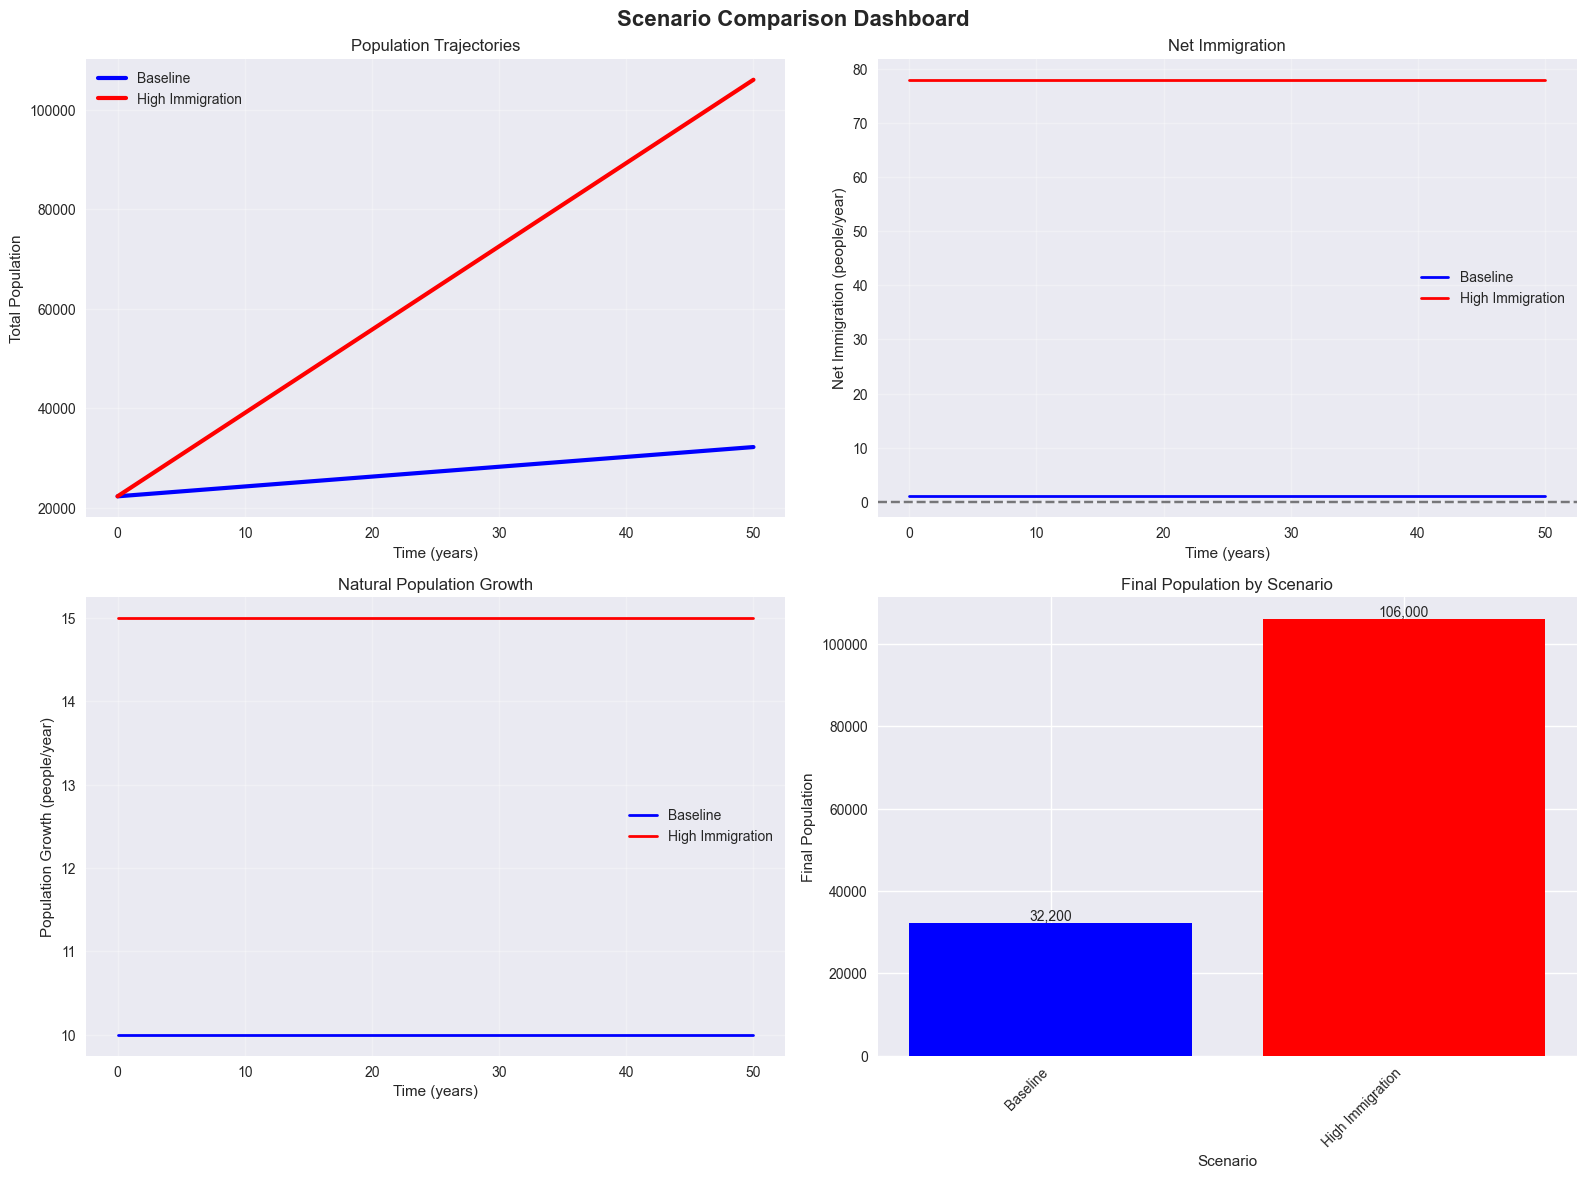

✅ Visualization complete


In [17]:
# Create scenario comparison visualizations
if simulation_results:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Scenario Comparison Dashboard', fontsize=16, fontweight='bold')
    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    # 1. Population trajectories
    for i, (scenario_name, results) in enumerate(simulation_results.items()):
        if 'Population' in results.columns:
            axes[0, 0].plot(results['time'], results['Population'], 
                           label=scenario_name, linewidth=3, color=colors[i % len(colors)])
    
    axes[0, 0].set_title('Population Trajectories')
    axes[0, 0].set_xlabel('Time (years)')
    axes[0, 0].set_ylabel('Total Population')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Net Immigration
    for i, (scenario_name, results) in enumerate(simulation_results.items()):
        if 'Net_Immigration' in results.columns:
            axes[0, 1].plot(results['time'], results['Net_Immigration'], 
                           label=scenario_name, linewidth=2, color=colors[i % len(colors)])
    
    axes[0, 1].set_title('Net Immigration')
    axes[0, 1].set_xlabel('Time (years)')
    axes[0, 1].set_ylabel('Net Immigration (people/year)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # 3. Population Growth
    for i, (scenario_name, results) in enumerate(simulation_results.items()):
        if 'Population_Growth' in results.columns:
            axes[1, 0].plot(results['time'], results['Population_Growth'], 
                           label=scenario_name, linewidth=2, color=colors[i % len(colors)])
    
    axes[1, 0].set_title('Natural Population Growth')
    axes[1, 0].set_xlabel('Time (years)')
    axes[1, 0].set_ylabel('Population Growth (people/year)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Final population comparison
    scenario_names = list(simulation_results.keys())
    final_populations = []
    
    for scenario_name in scenario_names:
        results = simulation_results[scenario_name]
        if 'Population' in results.columns:
            final_populations.append(results['Population'].iloc[-1])
        else:
            final_populations.append(0)
    
    bars = axes[1, 1].bar(range(len(scenario_names)), final_populations, 
                         color=[colors[i % len(colors)] for i in range(len(scenario_names))])
    axes[1, 1].set_title('Final Population by Scenario')
    axes[1, 1].set_xlabel('Scenario')
    axes[1, 1].set_ylabel('Final Population')
    axes[1, 1].set_xticks(range(len(scenario_names)))
    axes[1, 1].set_xticklabels(scenario_names, rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, value in zip(bars, final_populations):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:,.0f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print('✅ Visualization complete')

## Summary

This notebook demonstrates:

- **Clean workflow** for system dynamics scenario analysis
- **Separation of concerns** between model structure and parameters
- **Calculator components** for derived quantities
- **Multidimensional modeling** with automatic consistency
- **Comparative analysis** across scenarios
- **Essential visualizations** for understanding results

The approach enables flexible scenario testing while maintaining model integrity and providing clear insights into parameter impacts.